# 05 - Exercise 3 Production Solution

This notebook is the fast, production-style path for Exercise 3.

Why it exists:

- the walkthrough notebook is optimized for understanding
- this notebook is optimized for running the solution quickly and exporting the final files

Final files produced by this notebook:

- `outputs/exercise_3_monthly_session_history_top_user.tsv`
- `outputs/exercise_3_forecast_next_3_months.tsv`
- `outputs/exercise_3_model_coefficients.tsv`
- `outputs/exercise_3_summary.md`


## Functions used in this notebook

### `create_spark_session(...)`
- **Description:** Starts the Spark session used for the final ML export notebook.
- **Input:** Notebook app name and optional Spark settings.
- **Output:** Configured `SparkSession`.
- **Why this operation is selected for efficiency:** The same optimized Spark profile is reused across all notebooks.

### `load_lastfm_events(...)`
- **Description:** Loads the normalized event dataset.
- **Input:** Spark session and project root.
- **Output:** Spark DataFrame of events.
- **Why this operation is selected for efficiency:** Reading Parquet avoids reparsing the raw TSV on every run.

### `summarize_sessions_from_events(...)`
- **Description:** Produces the session-level base table from the event data.
- **Input:** Event DataFrame and session gap rule.
- **Output:** Session summary DataFrame.
- **Why this operation is selected for efficiency:** The ML metric is defined on sessions, so this is the smallest useful grain for the forecast pipeline.

### `get_top_user_for_ml(session_summary_df)`
- **Description:** Identifies the user with the highest number of sessions.
- **Input:** Session summary DataFrame.
- **Output:** Python dictionary with the selected user metadata.
- **Why this operation is selected for efficiency:** The expensive distributed work is done before this step; the notebook then focuses only on one user.

### `run_monthly_forecast_for_top_user(session_summary_df, metric='session_count', forecast_periods=3)`
- **Description:** Runs the end-to-end monthly forecast for the selected top user and returns the history, forecast table, coefficients, and validation summary.
- **Input:** Session summary DataFrame, chosen metric, and number of forecast months.
- **Output:** `ForecastArtifacts` dataclass with all final ML outputs.
- **Why this operation is selected for efficiency:** The heavy session computation stays in Spark, while the small forecasting problem is solved in Pandas/NumPy, which is simple, reproducible, and cheap at this scale.


In [1]:
from pathlib import Path
import logging
import sys

logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')
logger = logging.getLogger('lastfm.notebook')

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


WindowsPath('C:/Users/GonzaloFigueroa/Documents/Private/BME/lastfm-analysis')

In [2]:
import matplotlib.pyplot as plt
from pyspark import StorageLevel

from src.spark_utils import create_spark_session
from src.sessionization import (
    ensure_lastfm_dataset_available,
    load_lastfm_events,
    resolve_lastfm_input_path,
    stage_lastfm_events_to_parquet,
    summarize_sessions_from_events,
)
from src.forecasting import get_top_user_for_ml, run_monthly_forecast_for_top_user


In [3]:
outputs_dir = PROJECT_ROOT / 'outputs'
outputs_dir.mkdir(exist_ok=True)

spark = create_spark_session(app_name='05-exercise-3-production-solution')
spark


In [4]:
raw_input_path = ensure_lastfm_dataset_available(PROJECT_ROOT)
parquet_path = stage_lastfm_events_to_parquet(spark, PROJECT_ROOT)
logger.info(f'Raw dataset path: {raw_input_path}')
logger.info(f'Prepared Parquet path: {parquet_path}')


INFO:lastfm.notebook:Raw dataset path: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\data\raw\lastfm-dataset-1K\userid-timestamp-artid-artname-traid-traname.tsv


INFO:lastfm.notebook:Prepared Parquet path: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\data\processed\lastfm_events_parquet


In [5]:
events_df = load_lastfm_events(spark, PROJECT_ROOT)
session_summary_df = summarize_sessions_from_events(events_df, gap_minutes=20).persist(StorageLevel.DISK_ONLY)
session_summary_df.count()


1041883

In [6]:
top_user_info = get_top_user_for_ml(session_summary_df)
top_user_info


{'user_id': 'user_000833',
 'session_count': 6897,
 'first_session_start': datetime.datetime(2005, 2, 20, 3, 42, 32),
 'last_session_end': datetime.datetime(2009, 5, 23, 16, 6, 37)}

In [7]:
forecast_artifacts = run_monthly_forecast_for_top_user(
    session_summary_df,
    metric='session_count',
    forecast_periods=3,
)

history_df = forecast_artifacts.history_df
forecast_df = forecast_artifacts.forecast_df
coefficients_df = forecast_artifacts.model_coefficients_df


In [8]:
history_df.tail(12)


,month_start,session_count,avg_session_duration_minutes,user_id,selected_metric,metric_name,top_user_session_count,last_available_month
40,2008-06-01,195.0,81.435470,user_000833,195.0,session_count,6897,2009-05-01
41,2008-07-01,237.0,65.645077,user_000833,237.0,session_count,6897,2009-05-01
42,2008-08-01,192.0,56.794010,user_000833,192.0,session_count,6897,2009-05-01
43,2008-09-01,143.0,60.128322,user_000833,143.0,session_count,6897,2009-05-01
44,2008-10-01,229.0,63.666448,user_000833,229.0,session_count,6897,2009-05-01
45,2008-11-01,231.0,53.327561,user_000833,231.0,session_count,6897,2009-05-01
46,2008-12-01,227.0,49.967401,user_000833,227.0,session_count,6897,2009-05-01
47,2009-01-01,219.0,52.595282,user_000833,219.0,session_count,6897,2009-05-01
48,2009-02-01,197.0,41.222081,user_000833,197.0,session_count,6897,2009-05-01
49,2009-03-01,192.0,38.011719,user_000833,192.0,session_count,6897,2009-05-01


In [9]:
forecast_df


,month_start,predicted_value,predicted_value_rounded,forecast_step,user_id,metric_name
0,2009-06-01,162.803844,163,1,user_000833,session_count
1,2009-07-01,191.882394,192,2,user_000833,session_count
2,2009-08-01,212.290956,212,3,user_000833,session_count


In [10]:
coefficients_df


,feature_name,coefficient
0,intercept,30.799183
1,time_index,1.333673
2,month_sin,-14.706777
3,month_cos,5.844643
4,lag_1,0.517077
5,lag_2,-0.138385
6,lag_3,0.014652
7,rolling_mean_3,0.131114


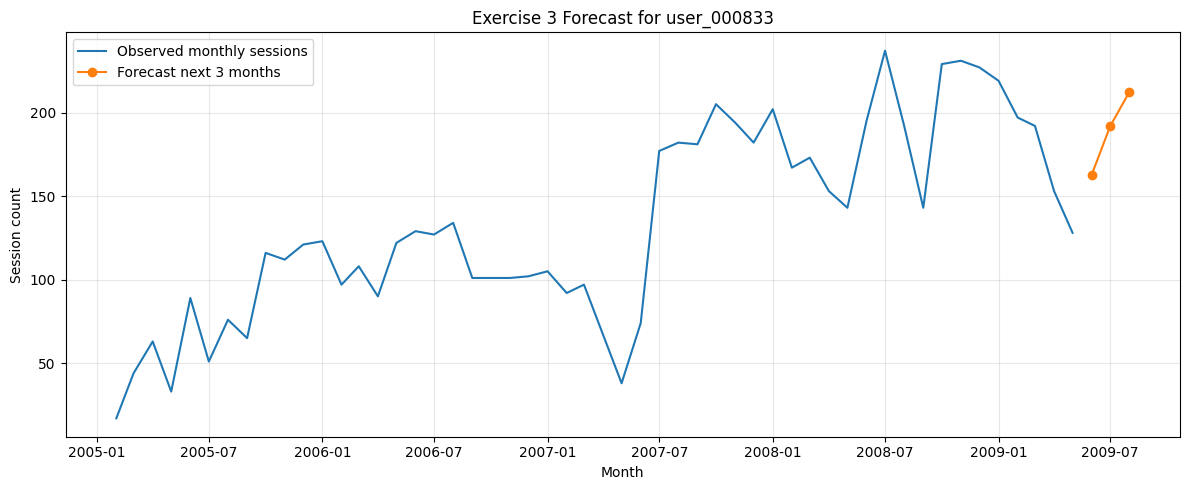

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(history_df['month_start'], history_df['selected_metric'], label='Observed monthly sessions')
plt.plot(forecast_df['month_start'], forecast_df['predicted_value'], marker='o', label='Forecast next 3 months')
plt.title(f'Exercise 3 Forecast for {forecast_artifacts.top_user_id}')
plt.xlabel('Month')
plt.ylabel('Session count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
forecast_artifacts.validation_mae


19.851042374608912

In [13]:
exercise_3_answer_tsv_path = PROJECT_ROOT / 'exercise_3_answer.tsv'
outputs_exercise_3_answer_tsv_path = outputs_dir / 'exercise_3_answer.tsv'
history_tsv_path = outputs_dir / 'exercise_3_monthly_session_history_top_user.tsv'
forecast_tsv_path = outputs_dir / 'exercise_3_forecast_next_3_months.tsv'
coefficients_tsv_path = outputs_dir / 'exercise_3_model_coefficients.tsv'
summary_md_path = outputs_dir / 'exercise_3_summary.md'

history_df.to_csv(history_tsv_path, index=False, sep='	')
forecast_df.to_csv(forecast_tsv_path, index=False, sep='	')
forecast_df.to_csv(exercise_3_answer_tsv_path, index=False, sep='	')
forecast_df.to_csv(outputs_exercise_3_answer_tsv_path, index=False, sep='	')
coefficients_df.to_csv(coefficients_tsv_path, index=False, sep='	')

summary_lines = [
    '# Coding Challenge - Exercise 3 Summary',
    '',
    '## Dataset',
    '',
    f"- Raw input file: `{raw_input_path}`",
    f"- Prepared Parquet dataset: `{parquet_path}`",
    '',
    '## Selected metric',
    '',
    '- Metric: `number of sessions per month`',
    '- Forecast horizon: `3 months`',
    '',
    '## Top user',
    '',
    f"- User ID: `{top_user_info['user_id']}`",
    f"- Total sessions: `{top_user_info['session_count']}`",
    f"- First session start: `{top_user_info['first_session_start']}`",
    f"- Last session end: `{top_user_info['last_session_end']}`",
    '',
    '## Forecast',
    '',
]
for _, row in forecast_df.iterrows():
    summary_lines.append(f"- {row['month_start'].date()}: {row['predicted_value']:.2f} (rounded={int(row['predicted_value_rounded'])})")
summary_lines.extend([
    '',
    '## Model',
    '',
    '- Approach: `linear autoregressive model with lag, trend, and month-seasonality features`',
])
if forecast_artifacts.validation_mae is not None:
    summary_lines.append(f"- Holdout validation MAE: `{forecast_artifacts.validation_mae:.2f}`")
summary_lines.extend([
    '',
    '## Output files',
    '',
    f"- `{exercise_3_answer_tsv_path.name}`",
    f"- `{history_tsv_path.name}`",
    f"- `{forecast_tsv_path.name}`",
    f"- `{coefficients_tsv_path.name}`",
])
summary_md_path.write_text('\n'.join(summary_lines), encoding='utf-8')

logger.info(f'Saved: {exercise_3_answer_tsv_path}')
logger.info(f'Saved: {outputs_exercise_3_answer_tsv_path}')
logger.info(f'Saved: {history_tsv_path}')
logger.info(f'Saved: {forecast_tsv_path}')
logger.info(f'Saved: {coefficients_tsv_path}')
logger.info(f'Saved: {summary_md_path}')


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\exercise_3_answer.tsv


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\outputs\exercise_3_answer.tsv


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\outputs\exercise_3_monthly_session_history_top_user.tsv


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\outputs\exercise_3_forecast_next_3_months.tsv


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\outputs\exercise_3_model_coefficients.tsv


INFO:lastfm.notebook:Saved: C:\Users\GonzaloFigueroa\Documents\Private\BME\lastfm-analysis\outputs\exercise_3_summary.md


In [14]:
spark.stop()
